## Loading and Pre-Cleaning

Import libraries and modules

In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

Load dataset and examine structure

In [4]:
url = "https://raw.githubusercontent.com/andrelewis-blip/Default-Prediction-Project/refs/heads/main/Loan_Default.csv"

df = pd.read_csv(url, encoding="latin1", sep=",")
print("Dimensions of dataset:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nSample Rows:")
print(df.head())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nBasic Statistics:")
print(df.describe())

Dimensions of dataset:
(148670, 32)

Column Names:
Index(['loan_limit', 'Gender', 'approv_in_adv', 'loan_type', 'loan_purpose',
       'Credit_Worthiness', 'open_credit', 'business_or_commercial',
       'loan_amount', 'rate_of_interest', 'Interest_rate_spread',
       'Upfront_charges', 'term', 'Neg_ammortization', 'interest_only',
       'lump_sum_payment', 'property_value', 'construction_type',
       'occupancy_type', 'Secured_by', 'total_units', 'income', 'credit_type',
       'Credit_Score', 'co-applicant_credit_type', 'age',
       'submission_of_application', 'LTV', 'Region', 'Security_Type', 'Status',
       'dtir1'],
      dtype='str')

Data Types:
loan_limit                       str
Gender                           str
approv_in_adv                    str
loan_type                        str
loan_purpose                     str
Credit_Worthiness                str
open_credit                      str
business_or_commercial           str
loan_amount                    int64


We collect pre-cleaning data and export to Excel which will help to inform decision making as it relates to cleaning the dataset.

In [3]:
summary=pd.DataFrame()
# All variables
summary["Variable Name"]=df.columns
summary["Data Type"]=df.dtypes.values
summary["No. Unique Values"] = df.nunique().values
summary["Sample Values"] = summary["Variable Name"].map(
    lambda col: ", ".join(map(str, df[col].dropna().unique()[:5]))
)
summary["Missing %"] = summary["Variable Name"].map(df.isnull().mean() * 100)
# Categorical columns
cat_cols = df.select_dtypes(include=['object', 'string']).columns
summary["Top Category Frequency (%)"] = None
for col in cat_cols:
    top_freq = df[col].value_counts(normalize=True).iloc[0] * 100
    summary.loc[summary["Variable Name"] == col, "Top Category Frequency (%)"] = top_freq
#Numerical Columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
summary["Num: Std"] = summary["Variable Name"].map(df.std(numeric_only=True))
summary["Num: Min"] = summary["Variable Name"].map(df.min(numeric_only=True))
summary["Num: Max"] = summary["Variable Name"].map(df.max(numeric_only=True))
correlations = df.corr(numeric_only=True)["Status"]
summary["Correlation with Status"] = summary["Variable Name"].map(correlations)
#print(summary)
#summary.to_excel("data_summary.xlsx", index=False)

## Data Cleaning & Preparation

Drop columns with low variability; Define target y and features matrix X; For selected variables with missing values, we add missing indicators column to X

In [ ]:
df=df.drop(columns=["Security_Type","total_units","Secured_by","construction_type"])
df=df.drop(columns=["Interest_rate_spread"])
y = df["Status"]
X = df.drop("Status", axis=1)
#X["interest_missing"] = X["rate_of_interest"].isnull().astype(int) #exclude due to perfect performance
X["property_value_missing"] = X["property_value"].isnull().astype(int)
X["income_missing"] = X["income"].isnull().astype(int)
X["dtir1_missing"] = X["dtir1"].isnull().astype(int)

We split X and y into train and test sets. We define numerical columns and categorical columns of X. 

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X_train.select_dtypes(include=["object"]).columns

C:\Users\andre\AppData\Local\Temp\ipykernel_19672\3481788256.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_train.select_dtypes(include=["object"]).columns


Perform imputation for missing values

In [6]:
# Numeric
num_imputer = SimpleImputer(strategy="median")
num_imputer.fit(X_train[num_cols])
X_train[num_cols] = num_imputer.transform(X_train[num_cols])
X_test[num_cols] = num_imputer.transform(X_test[num_cols])
# Categorical
cat_imputer = SimpleImputer(strategy="most_frequent")
cat_imputer.fit(X_train[cat_cols])
X_train[cat_cols] = cat_imputer.transform(X_train[cat_cols])
X_test[cat_cols] = cat_imputer.transform(X_test[cat_cols])

Encoding of categorical variables. (For decision trees-encoding is optional, for logistic regression and KNN, encoding is very critical)

In [7]:
#For encoding of categorical variables, we split into nominal and ordinal
cat_ord_cols = ["age"]
cat_nom_cols = [col for col in cat_cols if col not in cat_ord_cols]

#One Hot Encoding of nominal vars
ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
#1. Create arrays captured encoded columns
X_train_nom_encoded = ohe.fit_transform(X_train[cat_nom_cols])
X_test_nom_encoded = ohe.transform(X_test[cat_nom_cols])
#2. Convert arrays to dataframes
train_nom_df = pd.DataFrame(X_train_nom_encoded, columns=ohe.get_feature_names_out(cat_nom_cols), index=X_train.index)
test_nom_df = pd.DataFrame(X_test_nom_encoded, columns=ohe.get_feature_names_out(cat_nom_cols), index=X_test.index)
#3. Drop original nominal columns from the DFs
X_train = X_train.drop(columns=cat_nom_cols)
X_test = X_test.drop(columns=cat_nom_cols)
#4. Add in the encoded columns
X_train = pd.concat([X_train, train_nom_df], axis=1)
X_test = pd.concat([X_test, test_nom_df], axis=1)
#will now have encoded nominal variables

#Ordinal Encoding
age_order = [['<25', '25-34', '35-44', '45-54', '55-64','65-74','>74']]
#the unique values of X_train["age"] after imputation were printed to populate this list
ord_encoder = OrdinalEncoder(categories=age_order)
X_train[cat_ord_cols] = ord_encoder.fit_transform(X_train[cat_ord_cols]) #reassigns to X_train ordinal columns
X_test[cat_ord_cols] = ord_encoder.transform(X_test[cat_ord_cols]) #reassigns to X_test ordinal columns

We now write code to scale the numeric variables. Many models rely on distances and gradients and having one feature that has possibly larger values will lead to its dominance in the model and erroneous modelling. (For decision trees-scaling is optional, for logistic regression and KNN, scaling is very critical). It is important that we exclude the binary missing indicators columns from num_cols as they should not be scaled. 

In [8]:
scaler = StandardScaler()
#Note that num_cols excludes the OHE columns that were added but includes missing indicator columns which must be removed
indicator_cols = [
    "interest_missing",
    "property_value_missing",
    "income_missing",
    "dtir1_missing"
]
num_cols = [col for col in num_cols if col not in indicator_cols]
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

We now have X_train, X_test, y_train, y_test which are ready to be passed into our models.

## Algorithm Implementations

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_curve, roc_auc_score
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, GridSearchCV
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

### Logistic Regression

Best Params: {'lr__C': 10}
Best CV AUC: 0.8598352929526911
[[19661  2745]
 [ 2077  5251]]
              precision    recall  f1-score   support

           0       0.90      0.88      0.89     22406
           1       0.66      0.72      0.69      7328

    accuracy                           0.84     29734
   macro avg       0.78      0.80      0.79     29734
weighted avg       0.84      0.84      0.84     29734



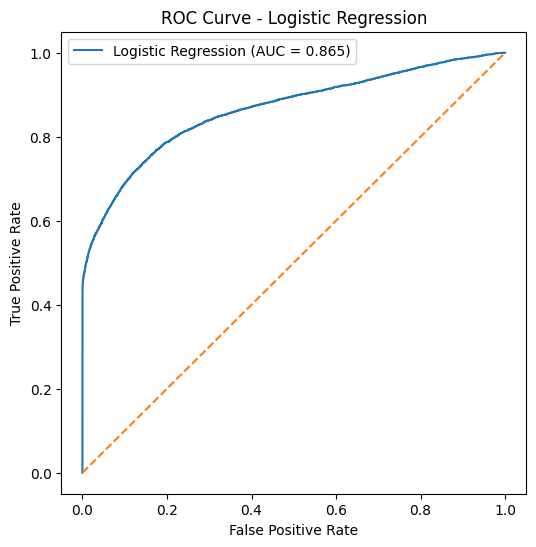

In [10]:
log_reg = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('lr', LogisticRegression(max_iter=1000, random_state=42))
])

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

param_grid = {
    'lr__C': [0.1, 1, 10]
}

grid = GridSearchCV(
    estimator=log_reg,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=skf,
    n_jobs=-1
)
grid.fit(X_train, y_train)
print("Best Params:", grid.best_params_)
print("Best CV AUC:", grid.best_score_)

best_model = grid.best_estimator_
#log_reg.fit(X_train, y_train)
y_pred = best_model.predict(X_test)
#y_pred = log_reg.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
print(cm)
print(classification_report(y_test, y_pred))


y_probs = best_model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc_score = roc_auc_score(y_test, y_probs)

# Plot ROC curve
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {auc_score:.3f})")
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()

plt.show()

In [16]:
import pandas as pd

coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": best_model.named_steps['lr'].coef_[0]
})

print(coef_df.sort_values(by="Coefficient", key=abs, ascending=False))
print(df.groupby("Status")["income"].apply(lambda x: x.isna().mean()))
print(df.groupby("Status")["rate_of_interest"].apply(lambda x: x.isna().mean()))

                               Feature  Coefficient
45                    credit_type_EQUI     4.794517
10              property_value_missing     4.466305
11                      income_missing    -2.769575
12                       dtir1_missing     1.683919
38               lump_sum_payment_lpsm     1.494434
46                     credit_type_EXP    -1.481373
43                     credit_type_CIB    -1.467064
44                    credit_type_CRIF    -1.428195
39           lump_sum_payment_not_lpsm    -1.076550
8                                  LTV     0.934721
50   submission_of_application_to_inst     0.855654
40                   occupancy_type_ir     0.830802
34           Neg_ammortization_neg_amm     0.745462
25                     loan_purpose_p2     0.677517
2                      Upfront_charges    -0.642145
31                     open_credit_opc     0.599652
1                     rate_of_interest    -0.515136
14                      loan_limit_ncf     0.512679
49  submissi

### K-Nearest Neighbour

Best Params: {'knn__n_neighbors': 7, 'knn__weights': 'distance'}
Best CV AUC: 0.932502990738206
[[18746  3660]
 [  847  6481]]

KNN Classification Report:

              precision    recall  f1-score   support

           0       0.96      0.84      0.89     22406
           1       0.64      0.88      0.74      7328

    accuracy                           0.85     29734
   macro avg       0.80      0.86      0.82     29734
weighted avg       0.88      0.85      0.86     29734



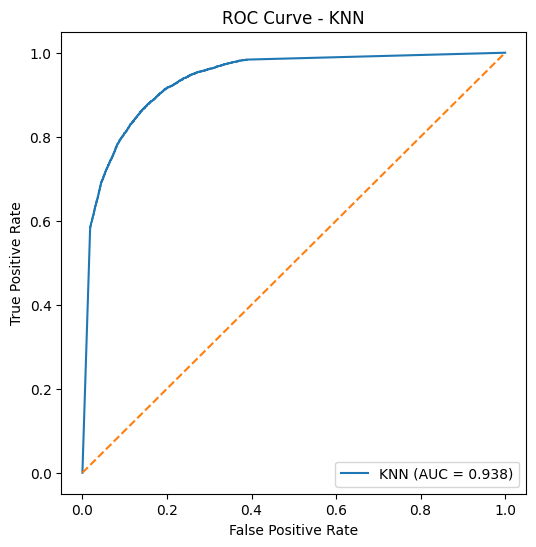

In [11]:
knn = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('knn', KNeighborsClassifier())
])

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

param_grid = {
    'knn__n_neighbors': [3, 5, 7],
    'knn__weights': ['uniform', 'distance']
}

grid = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=skf,
    n_jobs=-1
)
grid.fit(X_train, y_train)
print("Best Params:", grid.best_params_)
print("Best CV AUC:", grid.best_score_)

best_knn = grid.best_estimator_
y_pred_knn = best_knn.predict(X_test)

cm_knn = confusion_matrix(y_test, y_pred_knn)
print(cm_knn)
print("\nKNN Classification Report:\n")
print(classification_report(y_test, y_pred_knn))

y_probs = best_knn.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc_score = roc_auc_score(y_test, y_probs)

# Plot ROC curve
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"KNN (AUC = {auc_score:.3f})")
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - KNN")
plt.legend()

plt.show()

### Decision Trees

Best Params: {'dt__max_depth': 10, 'dt__min_samples_leaf': 2, 'dt__min_samples_split': 2}
Best CV AUC: 0.9993770164828225
Decision Tree Confusion Matrix:
 [[22332    74]
 [    5  7323]]

Decision Tree Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     22406
           1       0.99      1.00      0.99      7328

    accuracy                           1.00     29734
   macro avg       0.99      1.00      1.00     29734
weighted avg       1.00      1.00      1.00     29734



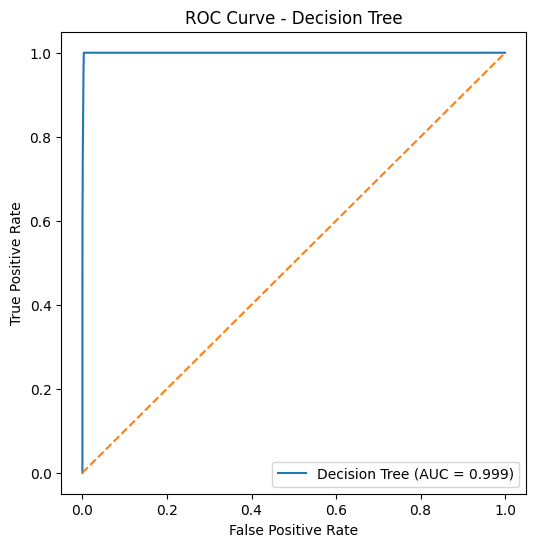

In [12]:
tree = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('dt', DecisionTreeClassifier(random_state=42))
])

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

param_grid = {
    'dt__max_depth': [None, 5, 10],
    'dt__min_samples_split': [2, 5, 10],
    'dt__min_samples_leaf': [1, 2, 4]
}

grid = GridSearchCV(
    estimator=tree,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=skf,
    n_jobs=-1
)
grid.fit(X_train, y_train)
print("Best Params:", grid.best_params_)
print("Best CV AUC:", grid.best_score_)

best_tree = grid.best_estimator_
y_pred_tree = best_tree.predict(X_test)

cm_tree = confusion_matrix(y_test, y_pred_tree)
print("Decision Tree Confusion Matrix:\n", cm_tree)
print("\nDecision Tree Classification Report:\n")
print(classification_report(y_test, y_pred_tree))


y_probs = best_tree.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc_score = roc_auc_score(y_test, y_probs)

# Plot ROC curve
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"Decision Tree (AUC = {auc_score:.3f})")
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Decision Tree")
plt.legend()

plt.show()

                               Feature  Importance
2                      Upfront_charges    0.943672
1                     rate_of_interest    0.046341
45                    credit_type_EQUI    0.009805
5                               income    0.000059
21                     loan_type_type1    0.000034
4                       property_value    0.000020
8                                  LTV    0.000012
11                      income_missing    0.000011
27                     loan_purpose_p4    0.000010
15                       Gender_Female    0.000008
9                                dtir1    0.000006
19                 approv_in_adv_nopre    0.000006
3                                 term    0.000005
6                         Credit_Score    0.000004
26                     loan_purpose_p3    0.000004
49  submission_of_application_not_inst    0.000003
13                       loan_limit_cf    0.000000
12                       dtir1_missing    0.000000
16                        Gende

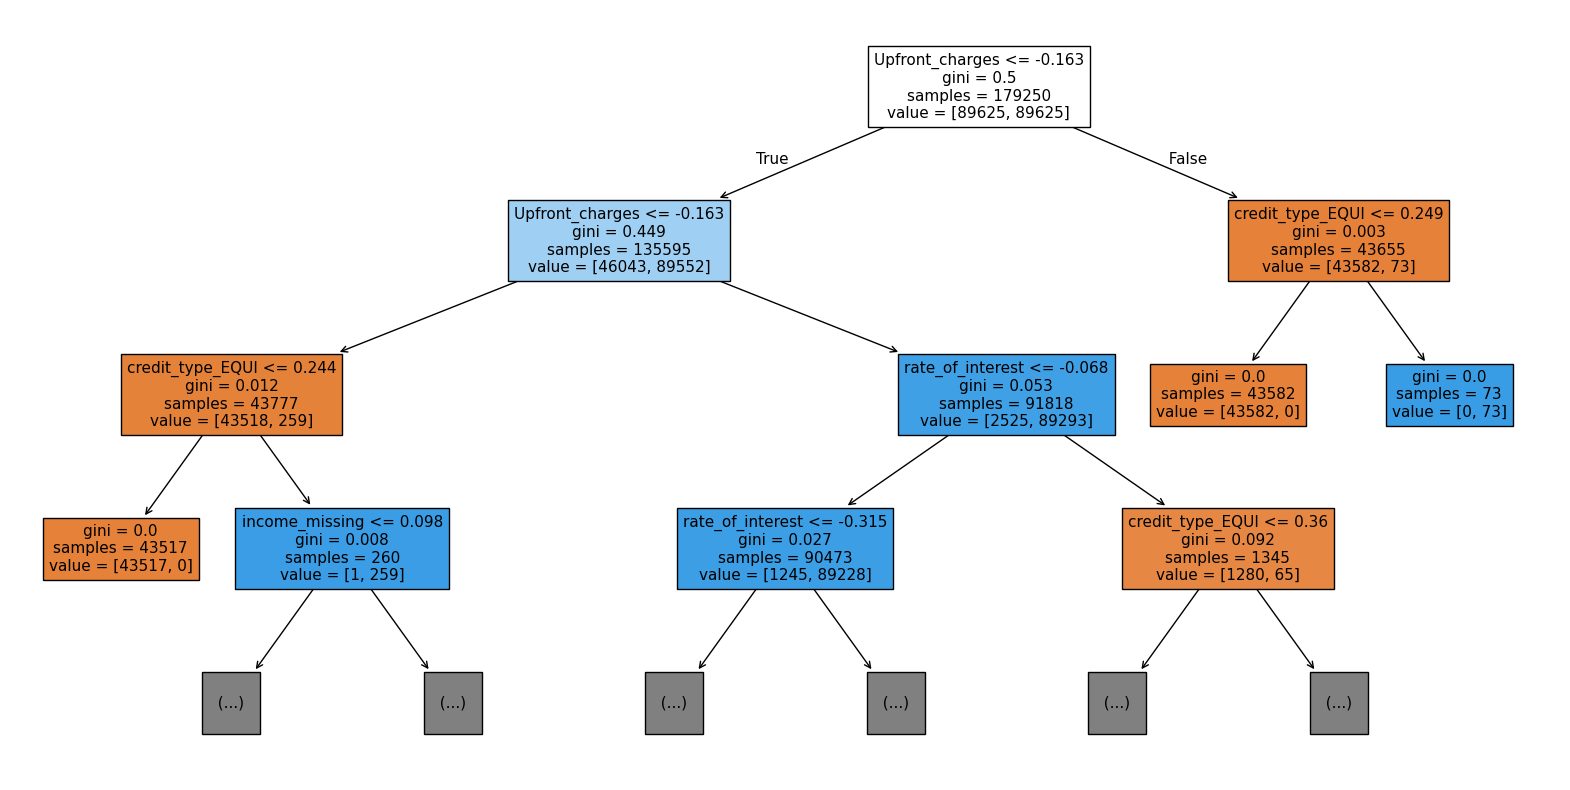

In [22]:
import pandas as pd

importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_tree.named_steps['dt'].feature_importances_
})

# Sort from most important to least
importance_df = importance_df.sort_values(by="Importance", ascending=False)

print(importance_df)

from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))

plot_tree(
    best_tree.named_steps['dt'],
    feature_names=X_train.columns,
    filled=True,
    max_depth=3
)

plt.show()

#df.groupby("Status")["Interest_rate_spread"].mean()

Checking for overfitting

In [24]:
y_train_pred = best_tree.predict(X_train)

from sklearn.metrics import classification_report

print("TRAINING PERFORMANCE:")
print(classification_report(y_train, y_train_pred))

print("TEST PERFORMANCE:")
print(classification_report(y_test, y_pred_tree))

TRAINING PERFORMANCE:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     89625
           1       0.99      1.00      1.00     29311

    accuracy                           1.00    118936
   macro avg       1.00      1.00      1.00    118936
weighted avg       1.00      1.00      1.00    118936

TEST PERFORMANCE:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     22406
           1       0.99      1.00      0.99      7328

    accuracy                           1.00     29734
   macro avg       0.99      1.00      1.00     29734
weighted avg       1.00      1.00      1.00     29734



Checking for leakage

In [25]:
import pandas as pd

duplicates = pd.merge(X_train, X_test, how='inner')
print("Duplicate rows:\n", len(duplicates))

df = pd.concat([X_train, y_train], axis=1)
print(df.corr(numeric_only=True)["Status"].sort_values(ascending=False))

Duplicate rows:
 0
Status                                1.000000
credit_type_EQUI                      0.589986
property_value_missing                0.585733
dtir1_missing                         0.436456
lump_sum_payment_lpsm                 0.182675
Neg_ammortization_neg_amm             0.155712
co-applicant_credit_type_EXP          0.143353
submission_of_application_to_inst     0.122683
loan_type_type2                       0.092219
business_or_commercial_b/c            0.092219
dtir1                                 0.082963
Gender_Sex Not Available              0.054754
loan_limit_ncf                        0.053003
age                                   0.043529
Region_south                          0.040629
LTV                                   0.038541
approv_in_adv_nopre                   0.037853
Credit_Worthiness_l2                  0.034170
loan_purpose_p2                       0.029526
occupancy_type_ir                     0.027703
Gender_Male                           0.0